In [1]:
# ── Cell 1 ───────────────────────────────────────────────────────────────────
import json, math, os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import geopandas as gpd
from shapely.geometry import shape, mapping, Polygon

import ee, geemap          # Google Earth Engine helpers
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()      # first time → browser OAuth
    ee.Initialize()

#  ► local helpers you pasted earlier
from touchterrain.common.hex_tesselate import hex_tile            # the code block you provided
import touchterrain.common.dem_tile_export as dte              # the DEM → STL functions block


In [2]:
# ── Cell 2 ───────────────────────────────────────────────────────────────────
# # A concave, non-rectangular polygon roughly 9 km wide (San Gabriels example)
# sample_aoi_geojson: Dict = {
#     "type": "Polygon",
#     "coordinates": [[
#         [-117.812, 34.249], [-117.770, 34.225], [-117.700, 34.236],
#         [-117.681, 34.281], [-117.716, 34.315], [-117.773, 34.301],
#         [-117.812, 34.249]  # closed ring
#     ]]
# }

sample_aoi_geojson: Dict = {
    "coordinates": [
      [
        [
          -118.46993293205853,
          34.40025991410893
        ],
        [
          -118.52575775793142,
          34.32951311487551
        ],
        [
          -118.38586867561615,
          34.28155523303343
        ],
        [
          -118.21730514426412,
          34.18296404370294
        ],
        [
          -117.88226627924956,
          34.12211153777912
        ],
        [
          -117.61793820910256,
          34.13035432993229
        ],
        [
          -117.37550145885413,
          34.195979833169744
        ],
        [
          -117.52086318632637,
          34.380109370210434
        ],
        [
          -117.85387455148347,
          34.44967938711228
        ],
        [
          -118.14064585862312,
          34.48808259019235
        ],
        [
          -118.46993293205853,
          34.40025991410893
        ]
      ]
    ],
    "type": "Polygon"
}

In [3]:
# Scaling
XY_SCALE = 2/100000 * 1000 # (since stl units should be mm, not m)
Z_EXAGGERATION = 1.5
Z_SCALE = Z_EXAGGERATION * XY_SCALE

In [4]:
# ── Cell 3 ───────────────────────────────────────────────────────────────────
HEX_DIAM_M          = 12000      #  hex “diameter” before scaling (m)
DEM_SCALE_M         = 31        #  DEM sample spacing
FRINGE_M            = DEM_SCALE_M * 3   # >1 pixel on every side
BOTTOM_OFFSET_M     = 10        # distance **below** the lowest DEM point
VERTICAL_EXAG       = 1.0       # z-scale applied to DEM before flooring
OUTPUT_DIR          = Path("hex_tiles_out").resolve()
OUTPUT_DIR.mkdir(exist_ok=True)

print("Hex real size: {:.2f} meters".format(HEX_DIAM_M*XY_SCALE))


Hex real size: 240.00 meters


In [5]:
# ── Cell 4 ───────────────────────────────────────────────────────────────────
hexes_gdf, outline_gdf = hex_tile(
    aoi_geojson   = sample_aoi_geojson,
    hex_diam      = HEX_DIAM_M,
    scale         = 1.0,
    orientation   = "pointy",
    keep_rule     = "intersect"     # keep hexes that intersect the AOI
)

# Pick a *single* projected CRS for every operation (auto-UTM for AOI centroid)
from pyproj import CRS
from touchterrain.common.hex_tesselate import utm_for_geometry
proj_crs = CRS.from_user_input(utm_for_geometry(shape(sample_aoi_geojson)))
print("Using projection:", proj_crs.to_string())


Using projection: EPSG:32611


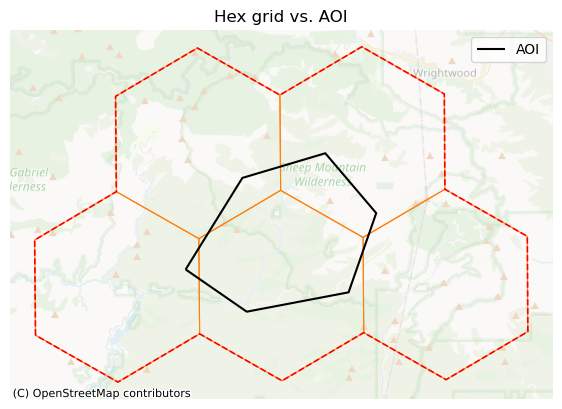

In [6]:
# ── Cell 8 ───────────────────────────────────────────────────────────────────
from touchterrain.common.hex_tesselate import show_tiling
show_tiling(sample_aoi_geojson, hexes_gdf, outline_gdf, title="Hex grid vs. AOI")


In [7]:
# ── Cell 5  (parallel / I-O bound) ───────────────────────────────────────────
"""
Download a fringed DEM for every hexagon **concurrently** and
collect the per-tile data + global minimum elevation.
"""
import math, concurrent.futures as cf
from shapely.geometry import mapping

dem_infos: List[Tuple[np.ndarray, Dict, Polygon, str]] = []
global_min_elev       = math.inf

# ---------- helper that runs in each thread ---------------------------------
def fetch_one(idx_hex) -> Tuple[Tuple[np.ndarray, Dict, Polygon, str], float]:
    idx, hex_poly_wgs = idx_hex
    hex_geo = mapping(hex_poly_wgs)

    # • DEM download (clip + fringe)
    dem_np, dem_img, bbox = dte.fetch_dem_with_fringe(
        geojson   = hex_geo,
        dem_id    = "USGS/SRTMGL1_003",
        scale     = DEM_SCALE_M,
        fringe_m  = FRINGE_M
    )

    # • local min elevation for this tile
    local_min = float(np.nanmin(dem_np))

    return (dem_np, bbox, hex_poly_wgs, f"tile_{idx:02d}"), local_min


# ---------- spin up a thread-pool (tune worker-count if API-limited) ---------
max_threads = min(16, len(hexes_gdf))        # 16 is a sensible ceiling for EE
print(f"Fetching DEMs with {max_threads} threads …")

with cf.ThreadPoolExecutor(max_workers=max_threads) as ex:
    futures = [
        ex.submit(fetch_one, (i, poly))
        for i, poly in enumerate(hexes_gdf.geometry, start=1)
    ]

    for f in cf.as_completed(futures):
        (dem_np, bbox, hex_poly, basename), local_min = f.result()
        dem_infos.append((dem_np, bbox, hex_poly, basename))
        global_min_elev = min(global_min_elev, local_min)
        print(f"✓ got {basename}")

# (optional) keep deterministic order for later loops
dem_infos.sort(key=lambda t: t[3])

print(f"Lowest elevation found across all tiles: {global_min_elev:.1f} m")


Fetching DEMs with 5 threads …
✓ got tile_03
✓ got tile_04
✓ got tile_05
✓ got tile_02
✓ got tile_01
Lowest elevation found across all tiles: 343.0 m


In [8]:
# ── Cell 6 ───────────────────────────────────────────────────────────────────
floor_abs_z = global_min_elev - BOTTOM_OFFSET_M
print(f"▶ All tiles will have a flat underside at Z = {floor_abs_z:.1f} m")


▶ All tiles will have a flat underside at Z = 333.0 m


In [14]:
# ── Cell 7 (parallel) ────────────────────────────────────────────────────────
"""
Create watertight, clipped STL tiles **in parallel**.
Each worker re-imports the helper module so that the child processes
don’t rely on objects pickled from the parent.
"""

import concurrent.futures as cf
import multiprocessing as mp
from pathlib import Path
from shapely.geometry import mapping  # only light objects cross process-boundaries


def build_one_tile(
    dem_np: np.ndarray,
    bbox: Dict,
    hex_poly_wgs,
    basename: str,
    *,
    floor_abs_z: float,
    proj_crs_str: str,
    out_dir: Path,
    vertical_exag: float = 1.0,
) -> str:
    """Runs _inside_ a worker process – returns basename when finished."""
    # -- local imports inside the worker ----------------------------
    import touchterrain.common.dem_tile_export as dte
    from pyproj import CRS

    rows, cols = dem_np.shape

    # ① DEM → surface mesh
    surf_mesh = dte.dem_to_surface_stl(
        dem_np=dem_np,
        bbox=bbox,
        # out_stl=out_dir / f"{basename}_surf.stl",
        vertical_exaggeration=vertical_exag,
        show_k3d=False,
    )

    # ② Make watertight with global floor
    solid_mesh = dte.dem_sheet_to_block(
        surf_mesh=surf_mesh,
        rows=rows,
        cols=cols,
        base_value=floor_abs_z,
        base_mode="absolute",
    )

    # # ③ Clip to hexagon and export
    # dte.clip_dem_block(
    #     dem_block=solid_mesh,
    #     aoi_geojson=mapping(hex_poly_wgs),
    #     out_stl=out_dir / f"{basename}.stl",
    #     project_crs=proj_crs_str,
    #     z_padding=0,
    #     xy_scale=XY_SCALE,
    #     z_scale=Z_SCALE,
    #     show_k3d=False,
    # )
        # ③ Clip to hexagon (no export yet)
    clipped = dte.clip_dem_block(
        dem_block=solid_mesh,
        aoi_geojson=mapping(hex_poly_wgs),
        # out_stl=None,                  # avoid exporting the plain clipped STL
        out_stl=out_dir / f"{basename}-pre-banding.stl",
        project_crs=proj_crs_str,
        z_padding=0,
        xy_scale=XY_SCALE,
        z_scale=Z_SCALE,
        show_k3d=False,
    )

    # ④ Add contour bands and export ONE STL containing multiple bodies
    banded = dte.add_contour_bands_one_stl(
        clipped,
        band_thickness_mm=0.5,
        band_interval_ft=1000,
        first_band_elev_ft=0,        # ABSOLUTE 0 ft MSL; change if you want a different datum
        z_unit_per_meter=Z_SCALE,    # exactly the z_scale you just used
        floor_abs_z_m=floor_abs_z,   # absolute meters used for the base
        elevation_mode="absolute",   # absolute bands (typical topo)
        out_stl=out_dir / f"{basename}-banded.stl",
        # debug=True,
        debug_log_path=out_dir / f"{basename}_bands_debug.log",
        boolean_strict=False,
    )

    return basename


# -- spin up as many workers as logical CPUs (tweak if RAM-limited) ----------
max_workers = mp.cpu_count()
print(f"Spawning {max_workers} worker processes …")

with cf.ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [
        ex.submit(
            build_one_tile,
            dem_np,
            bbox,
            hex_poly,
            basename,
            floor_abs_z=floor_abs_z,
            proj_crs_str=proj_crs.to_string(),
            out_dir=OUTPUT_DIR,
            vertical_exag=VERTICAL_EXAG,
        )
        for dem_np, bbox, hex_poly, basename in dem_infos
    ]

    for f in cf.as_completed(futures):
        print(f"✓ Finished {f.result()}.stl")

# # -- run sequentially (no multiprocessing) -----------------------------------
# print("Running sequentially (no worker pool) …")

# for dem_np, bbox, hex_poly, basename in dem_infos:
#     result = build_one_tile(
#         dem_np,
#         bbox,
#         hex_poly,
#         basename,
#         floor_abs_z=floor_abs_z,
#         proj_crs_str=proj_crs.to_string(),
#         out_dir=OUTPUT_DIR,
#         vertical_exag=VERTICAL_EXAG,
#     )
#     print(f"✓ Finished {result}.stl")


Running sequentially (no worker pool) …
⧗ Boolean intersection …
✓ Clipped STL saved: /TouchTerrain/standalone/hex_tiles_out/tile_01-pre-banding.stl
── Mesh Z diagnostics (mesh units = meters × z_scale) ──
Z_min(mesh): 9.989999771   Z_max(mesh): 46.439998627   Height(mesh): 36.449998856
Floor_abs(mesh): 9.990000000  (meters: 333.000)
Interval: 152.400 m (500 ft)  → mesh 4.572000000
Band thickness: 0.001 m (0.5 mm)  → mesh 0.500000000
First band center: 0.000 m (0 ft)  → mesh 0.000000000
Elevation mode: absolute
── Band centers ──
#00 center: mesh 13.716000000  |  457.200 m  |  1500.00 ft
#01 center: mesh 18.288000000  |  609.600 m  |  2000.00 ft
#02 center: mesh 22.860000000  |  762.000 m  |  2500.00 ft
#03 center: mesh 27.432000000  |  914.400 m  |  3000.00 ft
#04 center: mesh 32.004000000  |  1066.800 m  |  3500.00 ft
#05 center: mesh 36.576000000  |  1219.200 m  |  4000.00 ft
#06 center: mesh 41.148000000  |  1371.600 m  |  4500.00 ft
#07 center: mesh 45.720000000  |  1524.000 m  | 

In [ ]:
plot = k3d.plot()
plot += k3d.mesh(
    vertices=banded.vertices.astype(np.float32),
    indices=banded.faces.astype(np.uint32),
    wireframe=False,
    flat_shading=False
)
plot.display()


In [ ]:
print("Done!")